In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json
from scoit.cell_analysis import umap_visualize
from sklearn.preprocessing import MinMaxScaler

In [2]:
def save_edges_and_weights(save_dir, edges, weights, train_size, normalization):
    # Normalize 会让本来没有0的数据集产生零，即本来的最小值会变成0
    save_dir = Path(save_dir)
    nums_type = edges.max(0) + 1

    weights = weights.reshape(-1, 1)

    if normalization:
        scaler = MinMaxScaler()
        weights = scaler.fit_transform(weights)
        print('Normalize', scaler)

    train_data, test_data, train_weight, test_weight = train_test_split(edges, weights, train_size=train_size)
    train_weight = train_weight.reshape(-1)
    test_weight = test_weight.reshape(-1)

    np.savez(save_dir / 'train_data.npz', train_data=train_data, train_weight=train_weight,
             nums_type=nums_type)
    np.savez(save_dir / 'test_data.npz', test_data=test_data, test_weight=test_weight,
             nums_type=nums_type)


def save_metadata(save_dir, edges, train_size, nums_type, normalization):
    metadata = dict(
        train_size=train_size,
        normalization=normalization,
        num_edges=edges.shape[0],
        num_nodes=sum(nums_type),
        num_cells=nums_type[0],
        num_genes=nums_type[1],
        num_omics=nums_type[2],
    )
    np.savez(save_dir / 'metadata', **metadata)


In [3]:
from examples.case_studies.sci_CAR_analysis import load_data

expression_data, ATAC_data, labels = load_data()


In [4]:
len(labels)

8837

<Axes: >

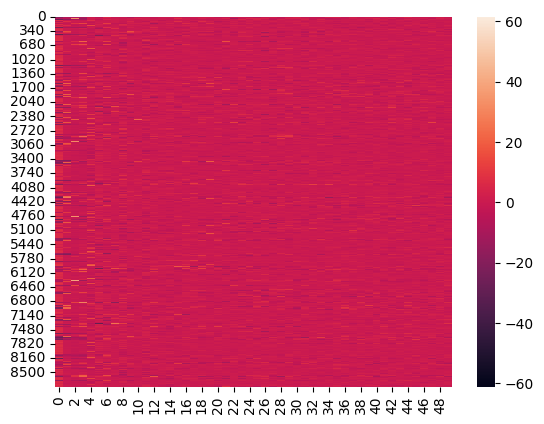

In [5]:
sns.heatmap(expression_data)

<Axes: >

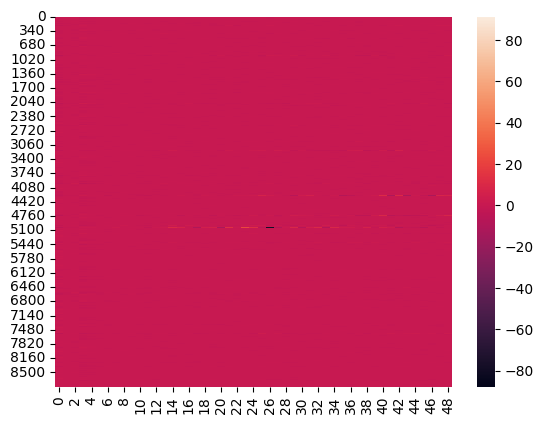

In [7]:
sns.heatmap(ATAC_data)

In [10]:
def remove_all_nan_columns(data, sigma=1):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])
    data = np.exp(data / sigma)
    return data

In [8]:
expression_data.shape, ATAC_data.shape

((8837, 50), (8837, 49))

In [15]:
expression_data_clean = remove_all_nan_columns(expression_data, sigma=100)
ATAC_data_clean = remove_all_nan_columns(ATAC_data, sigma=100)

Input #cols 50
After remove all nan 50
Input #cols 49
After remove all nan 49


Text(0.5, 1.0, 'expression_data_clean')

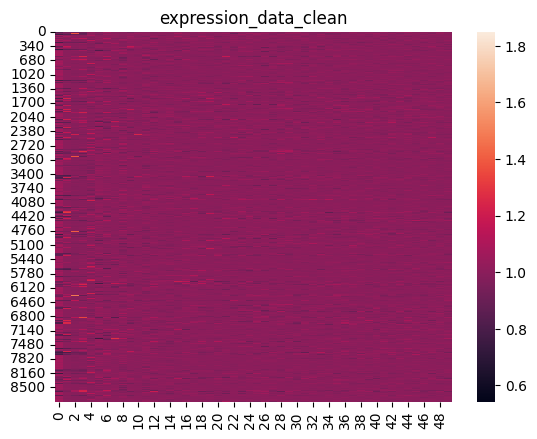

In [16]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

Text(0.5, 1.0, 'ATAC_data_clean')

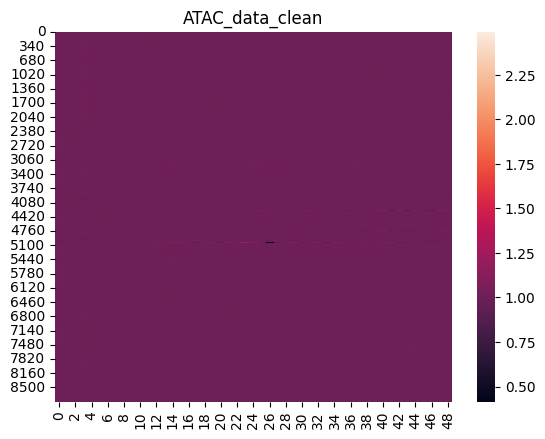

In [17]:
sns.heatmap(ATAC_data_clean)
plt.title('ATAC_data_clean')

In [18]:
expression_data_clean.min(), expression_data_clean.max()

(0.5430470286254996, 1.8485260006993662)

In [19]:
ATAC_data_clean.min(), ATAC_data_clean.max()

(0.4161878908906544, 2.489793078041033)

In [20]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(data)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [21]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(ATAC_data_clean, 1, expression_data_clean.shape[1])

In [22]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((441850, 3), (441850,), (433013, 3), (433013,))

In [23]:
expression_edges.max(0), methylation_edges.max(0)

(array([8836,   49,    0]), array([8836,   98,    1]))

In [24]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [25]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])

In [26]:
edges.shape, weights.shape

((874863, 3), (874863,))

In [28]:
np.any(np.abs(weights) < 1e-3)

False

In [29]:
save_edges_and_weights('./data/sci_CAR', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [30]:
train_data = np.load('./data/sci_CAR/train_data.npz', allow_pickle=True)
test_data = np.load('./data/sci_CAR/test_data.npz', allow_pickle=True)

In [31]:
np.any(train_data['train_weight'] == 0)

False

In [ ]:
np.any(test_data['test_weight'] == 0)

False

In [32]:
train_data['nums_type']

array([8837,   99,    2])

In [33]:
!python hgnn/main_torch.py --data sci_CAR --feature adj --loss bce --iter 50 --batch_size 256

1.0 -0.5
model_no_randomwalk
Use train_weight
Node type num [8837   99    2]
H.shape [(8837, 699890), (99, 699890), (2, 699890)]
embeddings.shape [(8837, 8938), (99, 8938), (2, 8938)]
embeddings_initial [False, False, False]
[0.9863752 1.0017827 1.0236766 ... 1.0013051 0.989473  0.9996425] 0.41618788 2.489793
walk type 
adding pad idx
dict_size 699890 874863
train data amount 699890
64
tensor([   0, 8837, 8936, 8938], device='cuda:0')
w.shape (8837, 101)
(8837, 101)
w.shape (99, 8839)
(99, 8839)
w.shape (2, 8936)
(2, 8936)
self.input_size [101, 8839, 8936]
inp 101 out 64 weight.shape torch.Size([64, 101])
fan_in 101 10.04987562112089
inp 8839 out 64 weight.shape torch.Size([64, 8839])
fan_in 8839 94.01595609256974
inp 8936 out 64 weight.shape torch.Size([64, 8936])
fan_in 8936 94.53041838477179
save embeddings
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
error MultipleEmbedding-1
 MultipleEmbedding-1   

In [34]:
!ls -lh ./*.npy

-rw-r--r-- 1 congfeng4 mscs 2.2M Nov 10 13:47 ./mymodel_0.npy
-rw-r--r-- 1 congfeng4 mscs 2.2M Nov 10 13:47 ./mymodel_0_origin.npy
-rw-r--r-- 1 congfeng4 mscs  25K Nov 10 13:47 ./mymodel_1.npy
-rw-r--r-- 1 congfeng4 mscs  25K Nov 10 13:47 ./mymodel_1_origin.npy
-rw-r--r-- 1 congfeng4 mscs  640 Nov 10 13:47 ./mymodel_2.npy
-rw-r--r-- 1 congfeng4 mscs  640 Nov 10 13:47 ./mymodel_2_origin.npy


In [35]:
!mkdir -p ./embeddings/hgnn/sci_CAR

In [36]:
!mv *.npy ./embeddings/hgnn/sci_CAR

In [37]:
cell_embeddings = np.load('./embeddings/hgnn/sci_CAR/mymodel_0.npy', allow_pickle=True)

In [40]:
cell_embeddings.shape, len(labels)

((8837, 64), 8837)

{'NMI': 0.005176990845523757,
 'ARI': 0.0011023775047463175,
 'FMI': 0.10353423938693232}

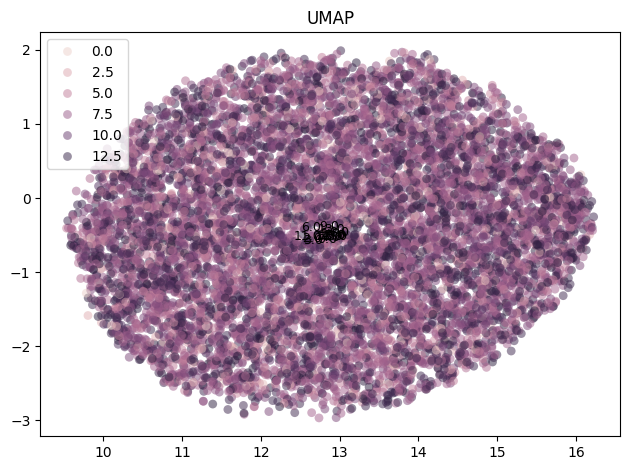

In [41]:
umap_visualize(cell_embeddings, labels)